Loading Data

In [ ]:
import pandas as pd
df = pd.read_csv('ScreenTime vs MentalWellness.csv')


Initial Checks

In [ ]:
# Get the number of rows and columns
print("Dataset shape (rows, columns):")
print(df.shape)
print("\n")

# View the first 5 rows of the dataset to get a sense of the data
print("First 5 rows of the dataset:")
print(df.head())
print("\n")

# Get a concise summary of the DataFrame, including data types and non-null values
print("Summary of the dataset:")
print(df.info())
print("\n")

# Get descriptive statistics for numerical columns
print("Descriptive statistics for numerical columns:")
print(df.describe())
print("\n")

# Get descriptive statistics for categorical columns
print("Descriptive statistics for categorical columns:")
print(df.describe(include='O'))
print("\n")

# Check for and count missing values in each column
print("Missing values per column:")
print(df.isnull().sum())


Dataset shape (rows, columns):
(400, 16)


First 5 rows of the dataset:
  user_id  age  gender occupation  work_mode  screen_time_hours  \
0   U0001   33  Female   Employed     Remote              10.79   
1   U0002   28  Female   Employed  In-person               7.40   
2   U0003   35  Female   Employed     Hybrid               9.78   
3   U0004   42    Male   Employed     Hybrid              11.13   
4   U0005   28    Male    Student     Remote              13.22   

   work_screen_hours  leisure_screen_hours  sleep_hours  sleep_quality_1_5  \
0               5.44                  5.35         6.63                  1   
1               0.37                  7.03         8.05                  3   
2               1.09                  8.69         6.48                  1   
3               0.56                 10.57         6.89                  1   
4               4.09                  9.13         5.79                  1   

   stress_level_0_10  productivity_0_100  exercise_minut

Examining Feature Distributions and Relationships

Generating histograms for numerical features...


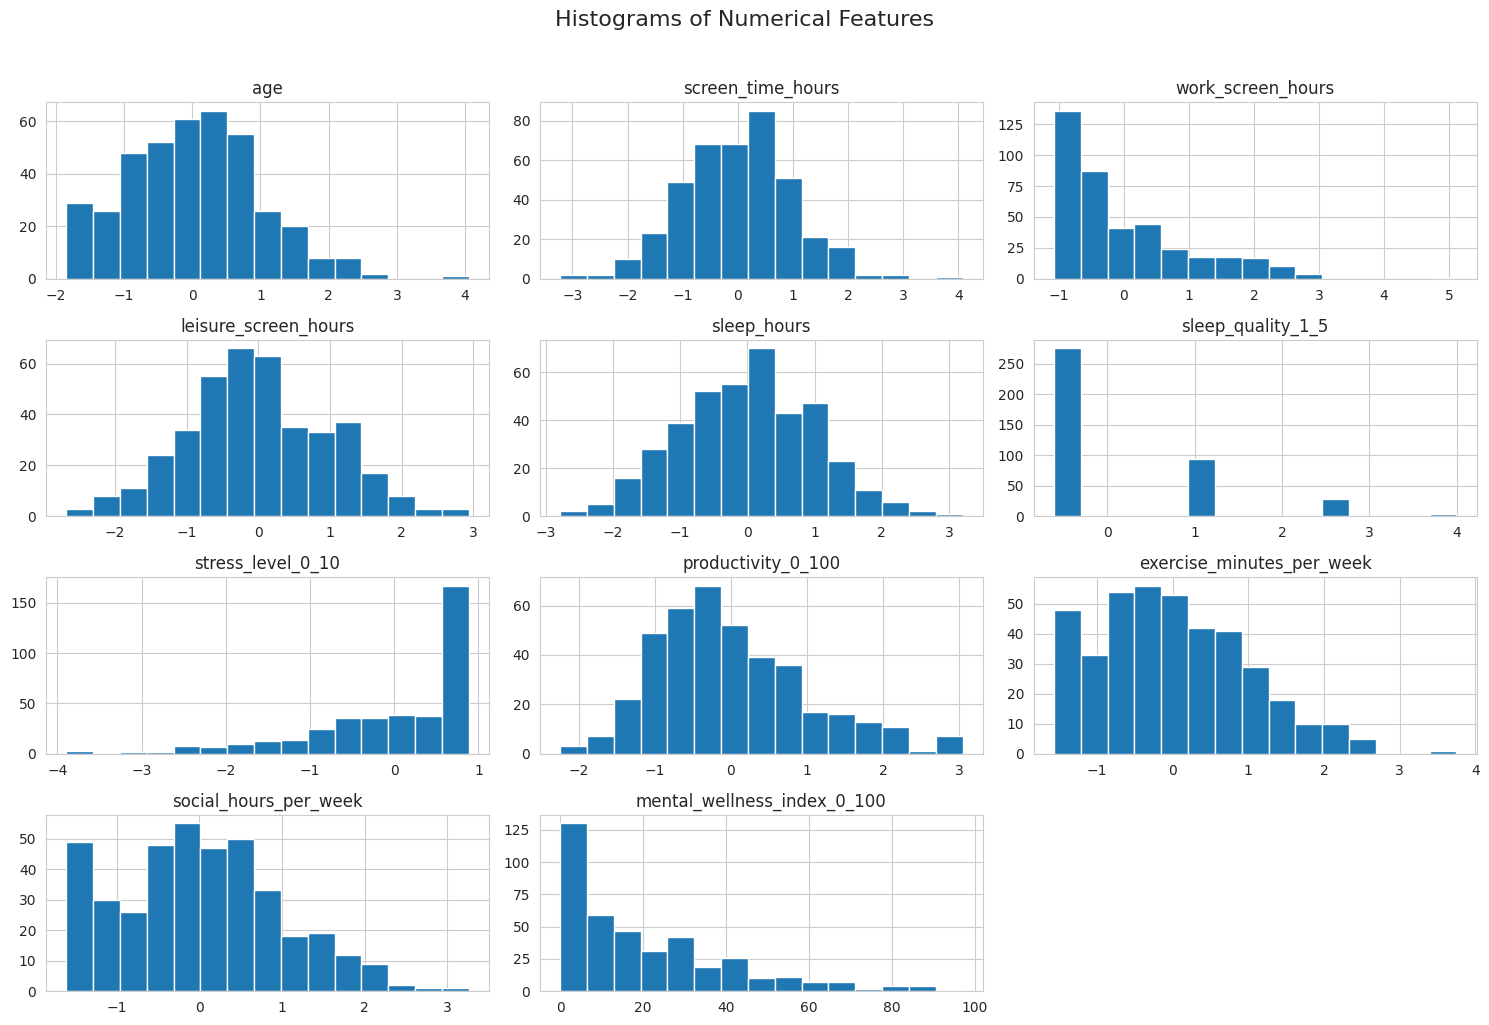

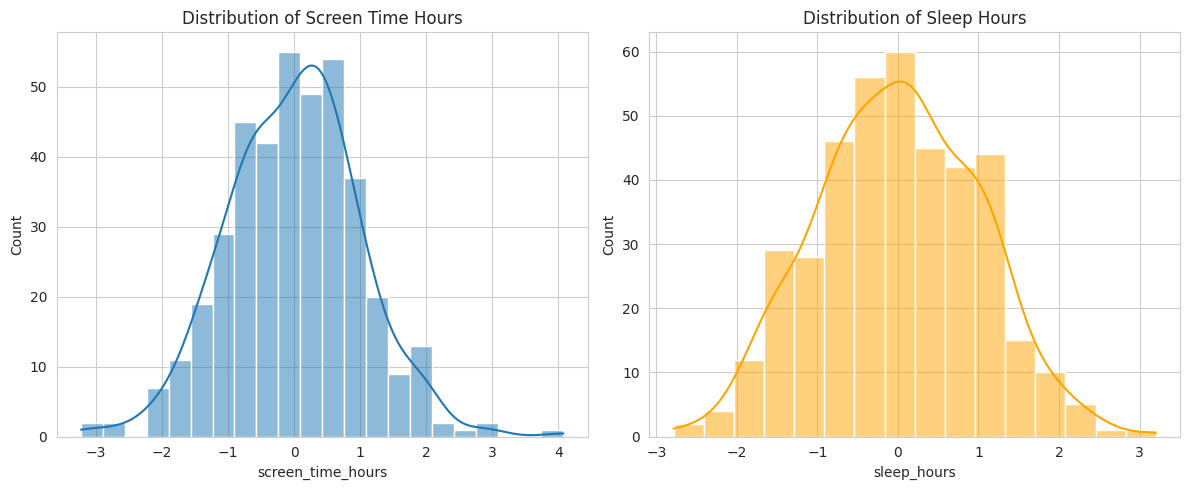

Generating pairplot for selected features...


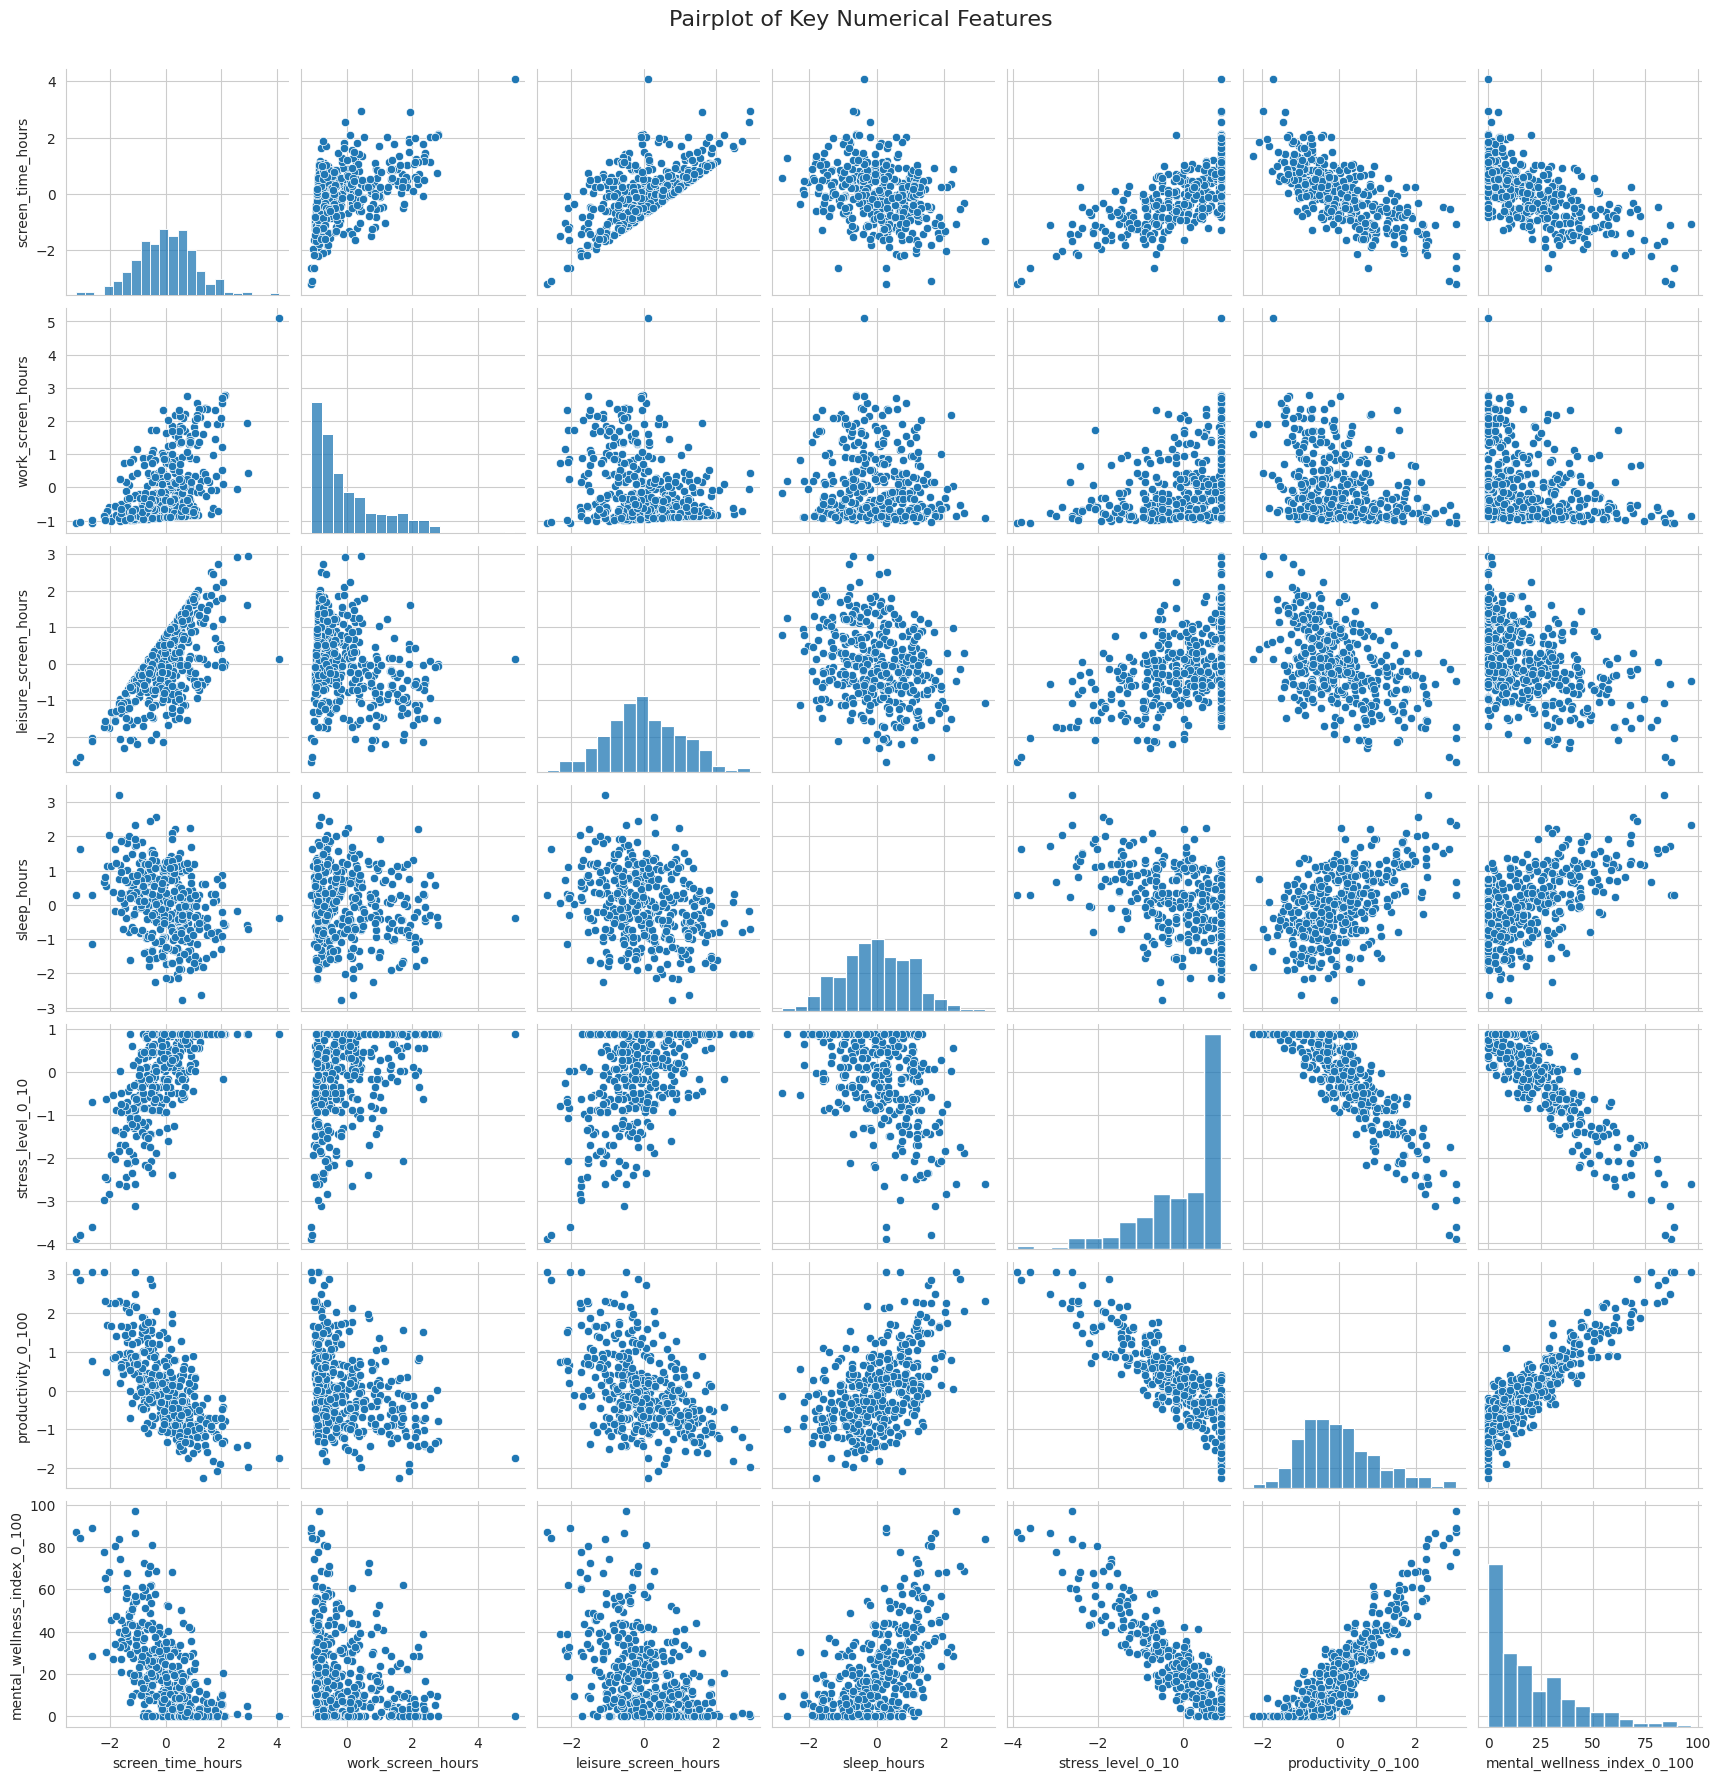

Generating correlation matrix heatmap...


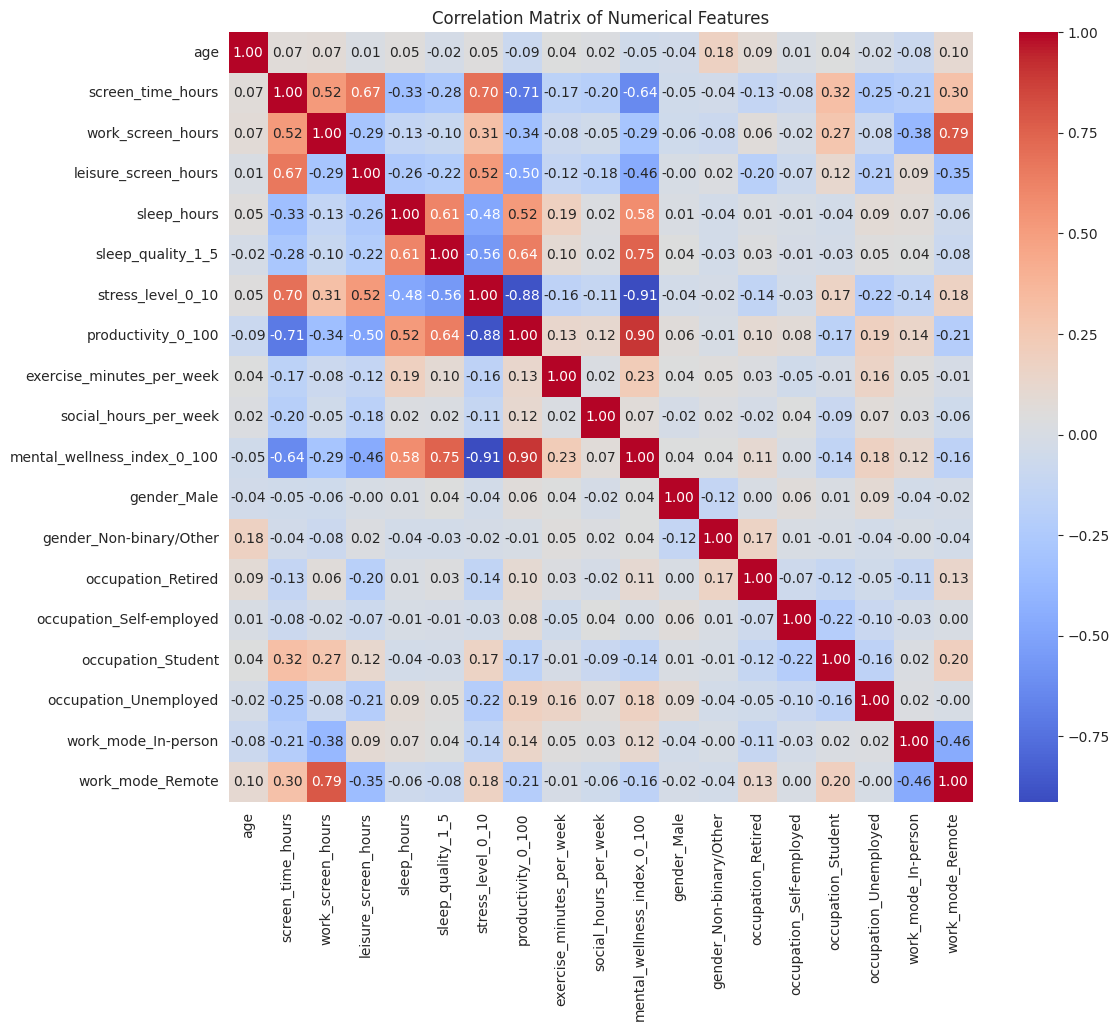

Generating scatter plot of screen time vs mental wellness...


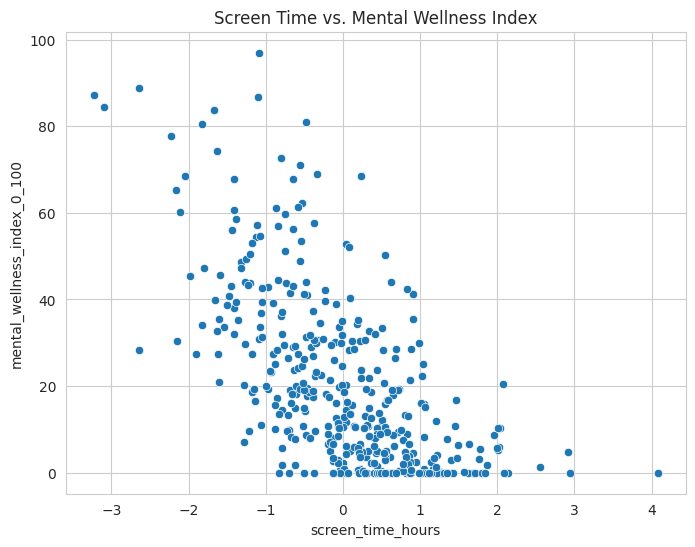

Generating boxplot of stress level by gender...


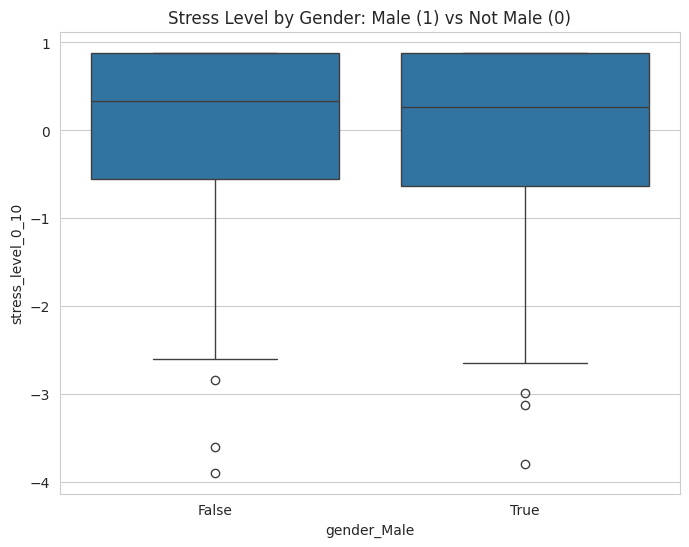

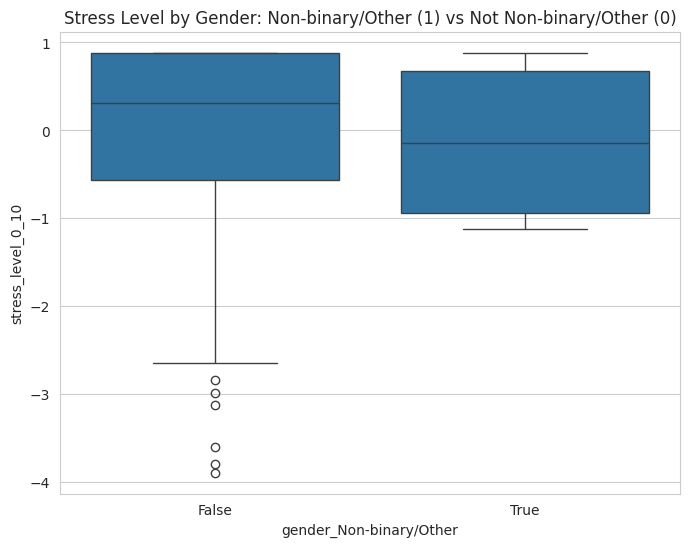

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots for better aesthetics
sns.set_style("whitegrid")

# --- Visualize feature distributions ---

# Plot histograms for all numerical columns to see their distributions
print("Generating histograms for numerical features...")
df.hist(bins=15, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# You can also create individual plots for specific features.
# For example, to visualize the distribution of 'screen_time_hours' and 'sleep_hours':
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['screen_time_hours'], kde=True)
plt.title('Distribution of Screen Time Hours')

plt.subplot(1, 2, 2)
sns.histplot(df['sleep_hours'], kde=True, color='orange')
plt.title('Distribution of Sleep Hours')
plt.tight_layout()
plt.show()

# --- Visualize relationships ---

# Use a pairplot to see the relationships between all numerical features
# Note: This can be slow for large datasets or many columns.
# It's better to select a few key columns to plot.
print("Generating pairplot for selected features...")
relevant_features = [
    'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours',
    'sleep_hours', 'stress_level_0_10', 'productivity_0_100',
    'mental_wellness_index_0_100'
]
sns.pairplot(df[relevant_features])
plt.suptitle('Pairplot of Key Numerical Features', y=1.02, fontsize=16)
plt.show()

# Create a correlation matrix heatmap to visualize correlations between numerical features
print("Generating correlation matrix heatmap...")
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# You can also create specific plots to explore the relationship between key variables.
# For example, a scatter plot of screen time vs. mental wellness index.
print("Generating scatter plot of screen time vs mental wellness...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x='screen_time_hours', y='mental_wellness_index_0_100', data=df)
plt.title('Screen Time vs. Mental Wellness Index')
plt.show()

# Use boxplots to visualize the relationship between a numerical and a categorical feature.
# For example, the relationship between 'gender' and 'stress_level_0_10'.
print("Generating boxplot of stress level by gender...")

# Plot boxplots for each one-hot encoded gender category
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender_Male', y='stress_level_0_10', data=df)
plt.title('Stress Level by Gender: Male (1) vs Not Male (0)')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='gender_Non-binary/Other', y='stress_level_0_10', data=df)
plt.title('Stress Level by Gender: Non-binary/Other (1) vs Not Non-binary/Other (0)')
plt.show()

Observation for histograms:

Age, Screen Time, and Work Hours: Most people's ages, total screen time, and work screen hours are clustered around an average value, forming a bell-shaped curve.

Stress Level: The majority of people report a low stress level, but a small number of individuals report very high stress levels.

Mental Wellness: Most people report a high mental wellness score, while a smaller group reports lower scores.

Sleep Quality: The data for sleep quality is mostly focused on one specific rating, with very few people giving other ratings.

Observations from pair plots:

The most important takeaway from the pair plots is the strong negative correlation between screen_time_hours and mental_wellness_index_0_100. This means as screen time increases, the mental wellness index tends to decrease.

Observations from heatmap:

The heatmap highlights several strong relationships, such as a strong positive correlation between work_screen_hours and work_mode_Remote (0.79), and a strong negative correlation between mental_wellness_index_0_100 and stress_level_0_10 (-0.91).

Observation for Box Plot:

Based on the box plot, the median self-reported stress level is highest for females, followed by males, and lowest for non-binary/other individuals. All three groups have a similar spread in the middle 50% of their reported stress levels.

In [ ]:
import pandas as pd


# Drop the 'Unnamed: 15' column since it contains no useful information
# This column was already dropped in a previous step, so this line is removed.


# Verify the column is dropped and check the new shape of the DataFrame
print("DataFrame shape after dropping the unnecessary column:", df.shape)
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

DataFrame shape after dropping the unnecessary column: (400, 20)

Missing values after preprocessing:
user_id                        0
age                            0
screen_time_hours              0
work_screen_hours              0
leisure_screen_hours           0
sleep_hours                    0
sleep_quality_1_5              0
stress_level_0_10              0
productivity_0_100             0
exercise_minutes_per_week      0
social_hours_per_week          0
mental_wellness_index_0_100    0
gender_Male                    0
gender_Non-binary/Other        0
occupation_Retired             0
occupation_Self-employed       0
occupation_Student             0
occupation_Unemployed          0
work_mode_In-person            0
work_mode_Remote               0
dtype: int64


Dropped unamed column to handle missing data.


In [ ]:
# Identify categorical columns to be encoded
categorical_cols = ['gender', 'occupation', 'work_mode']

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Print the new list of columns to see the one-hot encoded features
print("Columns after one-hot encoding:")
print(df.columns)
print("\nFirst 5 rows of the preprocessed DataFrame:")
print(df.head())


Columns after one-hot encoding:
Index(['user_id', 'age', 'screen_time_hours', 'work_screen_hours',
       'leisure_screen_hours', 'sleep_hours', 'sleep_quality_1_5',
       'stress_level_0_10', 'productivity_0_100', 'exercise_minutes_per_week',
       'social_hours_per_week', 'mental_wellness_index_0_100', 'gender_Male',
       'gender_Non-binary/Other', 'occupation_Retired',
       'occupation_Self-employed', 'occupation_Student',
       'occupation_Unemployed', 'work_mode_In-person', 'work_mode_Remote'],
      dtype='object')

First 5 rows of the preprocessed DataFrame:
  user_id  age  screen_time_hours  work_screen_hours  leisure_screen_hours  \
0   U0001   33              10.79               5.44                  5.35   
1   U0002   28               7.40               0.37                  7.03   
2   U0003   35               9.78               1.09                  8.69   
3   U0004   42              11.13               0.56                 10.57   
4   U0005   28              13.

In [ ]:
#Scaling Numerical Features

from sklearn.preprocessing import StandardScaler

# Identify numerical columns to be scaled
# The user_id is an identifier and should not be scaled as it is not a feature
numerical_cols = [
    'age', 'screen_time_hours', 'work_screen_hours',
    'leisure_screen_hours', 'sleep_hours', 'sleep_quality_1_5',
    'stress_level_0_10', 'productivity_0_100',
    'exercise_minutes_per_week', 'social_hours_per_week'
]

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the numerical data and transform it
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Print descriptive statistics to verify the scaling
print("Descriptive statistics after scaling numerical features:")
print(df[numerical_cols].describe().round(2))


Descriptive statistics after scaling numerical features:
          age  screen_time_hours  work_screen_hours  leisure_screen_hours  \
count  400.00             400.00             400.00                400.00   
mean     0.00              -0.00              -0.00                 -0.00   
std      1.00               1.00               1.00                  1.00   
min     -1.85              -3.23              -1.07                 -2.68   
25%     -0.77              -0.66              -0.77                 -0.62   
50%      0.03               0.03              -0.38                 -0.06   
75%      0.70               0.59               0.43                  0.71   
max      4.05               4.08               5.11                  2.93   

       sleep_hours  sleep_quality_1_5  stress_level_0_10  productivity_0_100  \
count       400.00             400.00             400.00              400.00   
mean         -0.00               0.00               0.00               -0.00   
std      

Prepare the data for modeling


In [15]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# 'user_id' is an identifier and should not be used as a feature
X = df.drop(['user_id', 'mental_wellness_index_0_100'], axis=1)
y = df['mental_wellness_index_0_100']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (320, 18)
X_test shape: (80, 18)
y_train shape: (320,)
y_test shape: (80,)


Define and tune the base models


In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# --- Model 1: Decision Tree Regressor ---
print("Starting GridSearchCV for Decision Tree...")
# Define the hyperparameter grid for Decision Tree
dt_param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a GridSearchCV object for Decision Tree
dt_grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the training data
dt_grid_search.fit(X_train, y_train)

# Report best parameters and validation score
best_dt = dt_grid_search.best_estimator_
print("\nBest parameters for Decision Tree:", dt_grid_search.best_params_)
print("Best cross-validation MSE for Decision Tree:", -dt_grid_search.best_score_)
print("-" * 50)


# --- Model 2: K-Nearest Neighbors Regressor ---
print("Starting GridSearchCV for K-Nearest Neighbors...")
# Define the hyperparameter grid for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2] # 1 for Manhattan distance, 2 for Euclidean distance
}

# Create a GridSearchCV object for KNN
knn_grid_search = GridSearchCV(
    KNeighborsRegressor(),
    knn_param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the training data
knn_grid_search.fit(X_train, y_train)

# Report best parameters and validation score
best_knn = knn_grid_search.best_estimator_
print("\nBest parameters for K-Nearest Neighbors:", knn_grid_search.best_params_)
print("Best cross-validation MSE for K-Nearest Neighbors:", -knn_grid_search.best_score_)
print("-" * 50)


# --- Model 3: Support Vector Regressor (SVR) ---
print("Starting GridSearchCV for Support Vector Regressor (SVR)...")
# Define the hyperparameter grid for SVR
svr_param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

# Create a GridSearchCV object for SVR
svr_grid_search = GridSearchCV(
    SVR(),
    svr_param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the training data
svr_grid_search.fit(X_train, y_train)

# Report best parameters and validation score
best_svr = svr_grid_search.best_estimator_
print("\nBest parameters for SVR:", svr_grid_search.best_params_)
print("Best cross-validation MSE for SVR:", -svr_grid_search.best_score_)
print("-" * 50)


Starting GridSearchCV for Decision Tree...
Fitting 5 folds for each of 45 candidates, totalling 225 fits

Best parameters for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validation MSE for Decision Tree: 61.42545265228464
--------------------------------------------------
Starting GridSearchCV for K-Nearest Neighbors...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters for K-Nearest Neighbors: {'n_neighbors': 9, 'p': 2, 'weights': 'distance'}
Best cross-validation MSE for K-Nearest Neighbors: 58.0088571729667
--------------------------------------------------
Starting GridSearchCV for Support Vector Regressor (SVR)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters for SVR: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation MSE for SVR: 29.068524195039224
--------------------------------------------------


Support Vector Regressor (SVR):

Result: This was the best-performing model, achieving the lowest Mean Squared Error (29.07).

Hyperparameter Tuning: It was tuned to use a linear kernel, suggesting a strong linear relationship between the input data and the mental wellness index.

K-Nearest Neighbors (KNN) Regressor:

Result: This was the second-best model, with a Mean Squared Error of 58.01.

Hyperparameter Tuning: It was tuned to find the optimal number of neighbors (9) and used Euclidean distance for measuring similarity.

Decision Tree Regressor:

Result: This model performed the worst, with a Mean Squared Error of 61.43.

Hyperparameter Tuning: It was tuned to a maximum depth of 5 to prevent overfitting, which can happen if the tree becomes too complex

Defining models and parameter grids

In [17]:
# Import necessary libraries
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Re-using the best-tuned base models from the previous step (assuming they are in memory)
# best_dt = dt_grid_search.best_estimator_
# best_knn = knn_grid_search.best_estimator_
# best_svr = svr_grid_search.best_estimator_

# If the previous output is not available, you can re-create the best estimators
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

best_dt = DecisionTreeRegressor(max_depth=5, min_samples_leaf=1, min_samples_split=5, random_state=42)
best_knn = KNeighborsRegressor(n_neighbors=9, p=2, weights='distance')
best_svr = SVR(C=1, gamma='scale', kernel='linear')


# --- 1. Bagging Ensemble (using Random Forest as an example) ---
rf_model = RandomForestRegressor(random_state=42)
# Using a smaller, more focused parameter grid for RandomizedSearchCV
rf_param_distributions = {
    'n_estimators': randint(50, 100),  # Reduced range and fewer options
    'max_depth': randint(5, 15),       # Reduced range
    'min_samples_leaf': randint(1, 3), # Smaller range, more efficient
    'min_samples_split': randint(2, 5) # Smaller range, more efficient
}

# --- 2. Boosting Model (using XGBoost) ---
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
# Using a smaller, more focused parameter grid for RandomizedSearchCV
xgb_param_distributions = {
    'n_estimators': randint(50, 100),  # Reduced range
    'learning_rate': uniform(0.05, 0.1), # Smaller range
    'max_depth': randint(3, 7),         # Reduced range
    'subsample': uniform(0.8, 0.2),      # Reduced range
    'colsample_bytree': uniform(0.8, 0.2) # Reduced range
}

# --- 3. Stacking Ensemble ---
estimators = [
    ('dt', best_dt),
    ('knn', best_knn),
    ('svr', best_svr)
]

# The meta-learner combines the predictions of the base models
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
)

# Tune the meta-learner with a much smaller, faster RandomizedSearchCV
stack_param_distributions = {
    'final_estimator__n_estimators': randint(20, 50),
    'final_estimator__learning_rate': uniform(0.01, 0.05)
}




Performing Randomized Search and report results

In [18]:
# Assuming X_train, y_train, and tuned base models are available from previous steps.

# --- Train and evaluate the Random Forest (Bagging) model with RandomizedSearchCV ---
print("Starting RandomizedSearchCV for Random Forest (Bagging)...")
rf_random_search = RandomizedSearchCV(
    rf_model,
    param_distributions=rf_param_distributions,
    n_iter=20, # Reduced number of iterations for speed
    scoring='neg_mean_squared_error',
    cv=3,      # Reduced cross-validation folds for speed
    n_jobs=-1,
    verbose=1,
    random_state=42
)
rf_random_search.fit(X_train, y_train)
print("\nBest parameters for Random Forest:", rf_random_search.best_params_)
print("Best cross-validation MSE for Random Forest:", -rf_random_search.best_score_)
print("-" * 50)

# --- Train and evaluate the XGBoost (Boosting) model with RandomizedSearchCV ---
print("Starting RandomizedSearchCV for XGBoost (Boosting)...")
xgb_random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=xgb_param_distributions,
    n_iter=20, # Reduced number of iterations for speed
    scoring='neg_mean_squared_error',
    cv=3,      # Reduced cross-validation folds for speed
    n_jobs=-1,
    verbose=1,
    random_state=42
)
xgb_random_search.fit(X_train, y_train)
print("\nBest parameters for XGBoost:", xgb_random_search.best_params_)
print("Best cross-validation MSE for XGBoost:", -xgb_random_search.best_score_)
print("-" * 50)

# --- Train and evaluate the Stacking model with RandomizedSearchCV ---
print("Starting RandomizedSearchCV for Stacking Regressor...")
stack_random_search = RandomizedSearchCV(
    stack_model,
    param_distributions=stack_param_distributions,
    n_iter=10, # Fewer iterations for the stacking model as it's more complex
    scoring='neg_mean_squared_error',
    cv=3,      # Reduced cross-validation folds for speed
    n_jobs=-1,
    verbose=1,
    random_state=42
)
stack_random_search.fit(X_train, y_train)
print("\nBest parameters for Stacking Regressor:", stack_random_search.best_params_)
print("Best cross-validation MSE for Stacking Regressor:", -stack_random_search.best_score_)
print("-" * 50)


Starting RandomizedSearchCV for Random Forest (Bagging)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters for Random Forest: {'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 51}
Best cross-validation MSE for Random Forest: 43.02051274969519
--------------------------------------------------
Starting RandomizedSearchCV for XGBoost (Boosting)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters for XGBoost: {'colsample_bytree': np.float64(0.9223306320976562), 'learning_rate': np.float64(0.050706630521971746), 'max_depth': 3, 'n_estimators': 98, 'subsample': np.float64(0.9049549320516779)}
Best cross-validation MSE for XGBoost: 37.15891845947042
--------------------------------------------------
Starting RandomizedSearchCV for Stacking Regressor...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters for Stacking Regressor: {'final_estimator__learning_rate': np.float64(0.045

XGBoost (Boosting) Regressor:

The XGBoost model was the most effective, achieving the lowest Mean Squared Error (37.16) for its predictions. It was tuned for optimal learning rate, tree depth, and the number of estimators.

Random Forest (Bagging) Regressor:
This model was the second-best performer, with a cross-validation MSE of 43.02. It averages predictions across 51 different decision trees to improve accuracy.

Stacking Regressor:

The Stacking model, which uses predictions from other models as input, performed the least effectively of the three ensembles, with a cross-validation MSE of 44.39.



In [29]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Assumed Preprocessing Steps ---
try:
    df = pd.read_csv('preprocessed_data.csv')
except FileNotFoundError:
    df = pd.read_csv('ScreenTime vs MentalWellness.csv')

    # Drop the 'Unnamed: 15' column since it contains no useful information
    df = df.loc[:, ~df.columns.str.contains('^Unnamed', case=False, na=False)]

    # Apply one-hot encoding
    df = pd.get_dummies(df, columns=['gender', 'occupation', 'work_mode'], drop_first=True)

    # Scale numerical features
    numerical_cols = [
        'age', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours',
        'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10',
        'productivity_0_100', 'exercise_minutes_per_week', 'social_hours_per_week'
    ]
    scaler = StandardScaler()
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Verify the column is dropped and check the new shape of the DataFrame
print("DataFrame shape after dropping the unnecessary column:", df.shape)
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

# Split data
X = df.drop(['user_id', 'mental_wellness_index_0_100'], axis=1)
y = df['mental_wellness_index_0_100']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 1. Instantiate the final, best-tuned models ---
# These models are created using the best parameters from your tuning outputs.
# Base Models
best_dt = DecisionTreeRegressor(max_depth=5, min_samples_leaf=1, min_samples_split=5, random_state=42)
best_knn = KNeighborsRegressor(n_neighbors=9, p=2, weights='distance')
best_svr = SVR(C=1, gamma='scale', kernel='linear')

# Ensemble Models
best_rf = RandomForestRegressor(
    max_depth=14, min_samples_leaf=1, min_samples_split=3, n_estimators=51, random_state=42
)
best_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    colsample_bytree=0.9223306320976562, learning_rate=0.050706630521971746, max_depth=3, n_estimators=98, subsample=0.9049549320516779,
    random_state=42
)
estimators_for_stacking = [('dt', best_dt), ('knn', best_knn), ('svr', best_svr)]
best_stack = StackingRegressor(
    estimators=estimators_for_stacking,
    final_estimator=xgb.XGBRegressor(
        objective='reg:squarederror', learning_rate=0.045403628889802275, n_estimators=41, random_state=42
    )
)

# --- 2. Fit all final models on the entire training set ---
print("\nFitting final models...")
best_dt.fit(X_train, y_train)
best_knn.fit(X_train, y_train)
best_svr.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)
best_stack.fit(X_train, y_train)

# --- 3. Define evaluation function ---
def evaluate_and_compare(models, X_train, y_train, X_test, y_test):
    results_list = []
    for name, model in models.items():
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        metrics = {
            'Model': name,
            'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'Train MAE': mean_absolute_error(y_train, y_train_pred),
            'Test MAE': mean_absolute_error(y_test, y_test_pred),
            'Train R2': r2_score(y_train, y_train_pred),
            'Test R2': r2_score(y_test, y_test_pred)
        }
        results_list.append(metrics)

    results_df = pd.DataFrame(results_list).set_index('Model')

    print("\n### Evaluation Results (on Test Data)")
    print(results_df.round(4).loc[:, ['Test RMSE', 'Test MAE', 'Test R2']].sort_values(by='Test RMSE'))
    print("\n" + "="*60 + "\n")

    print("### Overfitting Analysis (Train vs. Test RMSE)")
    overfit_analysis = pd.DataFrame({
        'Train RMSE': results_df['Train RMSE'],
        'Test RMSE': results_df['Test RMSE'],
        'Difference': results_df['Test RMSE'] - results_df['Train RMSE']
    }).round(4).sort_values(by='Difference', ascending=False)
    print(overfit_analysis)
    print("\n" + "="*60 + "\n")

    return results_df

# --- 4. Evaluate all models and present results ---
all_models = {
    "Decision Tree": best_dt,
    "KNN": best_knn,
    "SVR": best_svr,
    "Random Forest (Bagging)": best_rf,
    "XGBoost (Boosting)": best_xgb,
    "Stacking Regressor": best_stack
}

evaluate_and_compare(all_models, X_train, y_train, X_test, y_test)



DataFrame shape after dropping the unnecessary column: (400, 20)

Missing values after preprocessing:
user_id                        0
age                            0
screen_time_hours              0
work_screen_hours              0
leisure_screen_hours           0
sleep_hours                    0
sleep_quality_1_5              0
stress_level_0_10              0
productivity_0_100             0
exercise_minutes_per_week      0
social_hours_per_week          0
mental_wellness_index_0_100    0
gender_Male                    0
gender_Non-binary/Other        0
occupation_Retired             0
occupation_Self-employed       0
occupation_Student             0
occupation_Unemployed          0
work_mode_In-person            0
work_mode_Remote               0
dtype: int64

Fitting final models...

### Evaluation Results (on Test Data)
                         Test RMSE  Test MAE  Test R2
Model                                                
SVR                         5.2090    3.9655   0.9314

,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
Model,,,,,,
Decision Tree,4.616963e+00,7.647062,3.573344e+00,5.905499,0.948980,0.852151
KNN,6.421316e-07,7.924552,2.344989e-07,6.155168,1.000000,0.841226
SVR,5.107373e+00,5.209043,3.903940e+00,3.965542,0.937566,0.931397
Random Forest (Bagging),2.542915e+00,6.595349,1.861166e+00,5.160163,0.984523,0.890022
XGBoost (Boosting),3.655458e+00,5.952018,2.922464e+00,4.683551,0.968018,0.910431
Stacking Regressor,5.645164e+00,6.615294,4.427675e+00,4.971565,0.923726,0.889356


Model Performance Comparison




SVR: This individual base model showed the best overall performance with the lowest RMSE (5.21) and highest \(R^{2}\) (0.93) on the test data. The Support Vector Regressor (SVR) model was the most accurate for predicting mental wellness based on screen time and other factors. Its predictions were consistently the closest to the actual survey results, and it best captured the overall relationship between the variables.

XGBoost (Boosting): The boosting ensemble was the second-best model, performing better than the bagging and stacking ensembles.

Random Forest (Bagging): The bagging ensemble outperformed the stacking model but was less accurate than SVR and XGBoost.

Stacking: This ensemble performed worse than the bagging and boosting models, and also failed to improve upon the best individual model (SVR).

Individual Models: The SVR model significantly outperformed the other individual models (Decision Tree and KNN).


Stacking Performance Relative to Others:

The Stacking Regressor performed worse than the boosting and bagging ensembles. It also failed to surpass the best base model, the SVR. This indicates the stacking's complexity did not provide a performance benefit for this dataset.

Overfitting Analysis (Train vs. Test RMSE)

Overfitting occurs when a model performs significantly better on the training data than on unseen test data. The difference between training and test RMSE provides a good measure of this.

Minimal Overfitting: SVR

The SVR learned the fundamental link between screen time and mental wellness.

This means it will likely generalize very well to new data, making reliable predictions for the general population

Slight Overfitting: XGBoost and Stacking

These models learned the relationship with more detail, including some random noise from the training data.

They may make slightly less reliable predictions when encountering new, unusual screen habits

Moderate Overfitting:

The Random Forest and Decision Tree
These tree-based models created overly complex rules that essentially memorized specific training examples.

This makes their predictions less reliable for new individuals not perfectly matching those memorized patterns.

Severe Overfitting: KNN

 The KNN model displayed severe overfitting, with a perfect training score but poor test performance.

This causes it to perform very poorly on new data, as it failed to learn any general trends about screen time and mental wellness.


